# Infectivity Regression

In [1]:
import pandas as pd
import torch
import pickle
from tqdm import tqdm
from sklearn.neighbors import KernelDensity as KDE
import numpy as np
from tqdm import tqdm
import os
from datetime import datetime as dt

import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
from pyro.infer.predictive import Predictive

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns

In [2]:
pyro.set_rng_seed(0)
pyro.clear_param_store()

d = torch.float32
torch.set_default_dtype(d)

plt.rcParams["font.family"] = "Times New Roman"

run_MCMC = True
last_run_folder = 'model_infectivity/2024-01-20/'

---
## Load data

In [3]:
# Infectivity - constructs
data_dir='data/Infectivity/'
filename='infectivity_final_Dec15_23.csv'
cols=['new_name', 'WuG_norm_1', 'WuG_norm_2', 'WuG_norm_3', 'WuG_norm_avg']
constructs = pd.read_csv(data_dir+filename, usecols=cols)
constructs = constructs.dropna()
constructs['new_name'] = constructs['new_name'].apply(lambda x: x.capitalize() if x.islower() else x)

In [4]:
# Infectivity - vocs
data_dir='data/Infectivity/'
filename='infectivity_VoCs_Dec15_23.csv'
cols=['new_name', 'norm_WuG_1', 'norm_WuG_2', 'norm_WuG_3', 'norm_WuG_avg']
vocs = pd.read_csv(data_dir+filename, usecols=cols)
vocs = vocs.dropna()
vocs['new_name'] = vocs['new_name'].apply(lambda x: x.capitalize() if x.islower() else x)

In [5]:
# Infectivity - all
constructs = constructs.rename(columns={'new_name':'Name'})
vocs = vocs.rename(columns={'new_name':'Name', 'norm_WuG_1':'WuG_norm_1', 'norm_WuG_2':'WuG_norm_2', 'norm_WuG_3':'WuG_norm_3', 'norm_WuG_avg':'WuG_norm_avg'}) 
infectivity = pd.concat([constructs, vocs]).drop_duplicates()

# Remove avg and melt df
infectivity = infectivity.drop(columns='WuG_norm_avg')
infectivity = pd.melt(infectivity, id_vars=['Name'], value_vars=['WuG_norm_1', 'WuG_norm_2', 'WuG_norm_3'], var_name='Observation', value_name='Infectivity (WuG Norm)')
infectivity['Log10 Infectivity (WuG Norm)'] = infectivity['Infectivity (WuG Norm)'].apply(lambda x: np.log10(x))
infectivity = infectivity.drop(columns=['Observation', 'Infectivity (WuG Norm)'])
print(f'{len(infectivity)} infectivity results')

513 infectivity results


In [6]:
# Mutations
data_dir = 'data/Infectivity/'
filename = 'CEPI_order_summary - SARS-CoV-2.csv'
cols = ['new_name', 'All mutations', 'Base VoC']
mutations = pd.read_csv(data_dir+filename, usecols=cols).rename(columns={'new_name':'Name'})
mutations['Name'] = mutations['Name'].apply(lambda x: x.capitalize() if x.islower() else x)    # name VoCs consistently
mutations['All mutations'] = mutations['All mutations'].apply(lambda x: x.replace(' ', ''))    # remove any spaces between mutations in the list

# Remove D614G
mutations['All mutations'] = mutations['All mutations'].apply(lambda x: x.replace('D614G,',''))
mutations['All mutations'] = mutations['All mutations'].apply(lambda x: x.replace(',D614G',''))
mutations['All mutations'].loc[mutations['Name']=='WuG'] = None
mutations = pd.concat([mutations, pd.DataFrame([{'Name':'WT', 'All mutations':None}])])

mutations = mutations[mutations['All mutations']!='--']

print(f'{len(mutations)} sequences with known mutations')

147 sequences with known mutations


In [7]:
df = infectivity.merge(mutations, on='Name', how='inner').drop_duplicates()
df = df[~pd.isna(df['Log10 Infectivity (WuG Norm)'])]
df = df.sort_values(by=['Log10 Infectivity (WuG Norm)']).reset_index(drop=True)
print(f'{len(df)} infectivity results:')
df.head()

511 infectivity results:


,Name,Log10 Infectivity (WuG Norm),Base VoC,All mutations
0,WuG_pre2020_9a,-2.749995,WuhanG,"H69G,Y248D,R403T,N439R,T478K,E484V,F490R,S494R..."
1,BA.2.12.1-7a,-2.658193,BA.2.12.1,"T19I,L24del,P25del,P26del,A27S,G142D,K147N,S15..."
2,BA.2.12.1-7a,-2.573182,BA.2.12.1,"T19I,L24del,P25del,P26del,A27S,G142D,K147N,S15..."
3,BA.2.12.1-8a,-2.553039,BA.2.12.1,"K147N,S155R,L452R,F490R,Q493S,S494R,Q498Y,K529..."
4,BA.2.12.1-5a,-2.378361,BA.2.12.1,"T19I,L24del,P25del,P26del,A27S,G142D,K147N,S15..."


---
## QA Data

In [8]:
names = df[['Name', 'Base VoC']].groupby('Name').agg('count').reset_index()[df[['Name', 'Base VoC']].groupby('Name').agg('count').reset_index()['Base VoC']>3]['Name'].tolist()
print('Constructs with non-unique Base VoCs:')
print(' '+ ', '.join(names))

Constructs with non-unique Base VoCs:
 BA.2.12.1, BA.2.75, BA.2.86, BA.4.6, BA.5, WuG, XBB


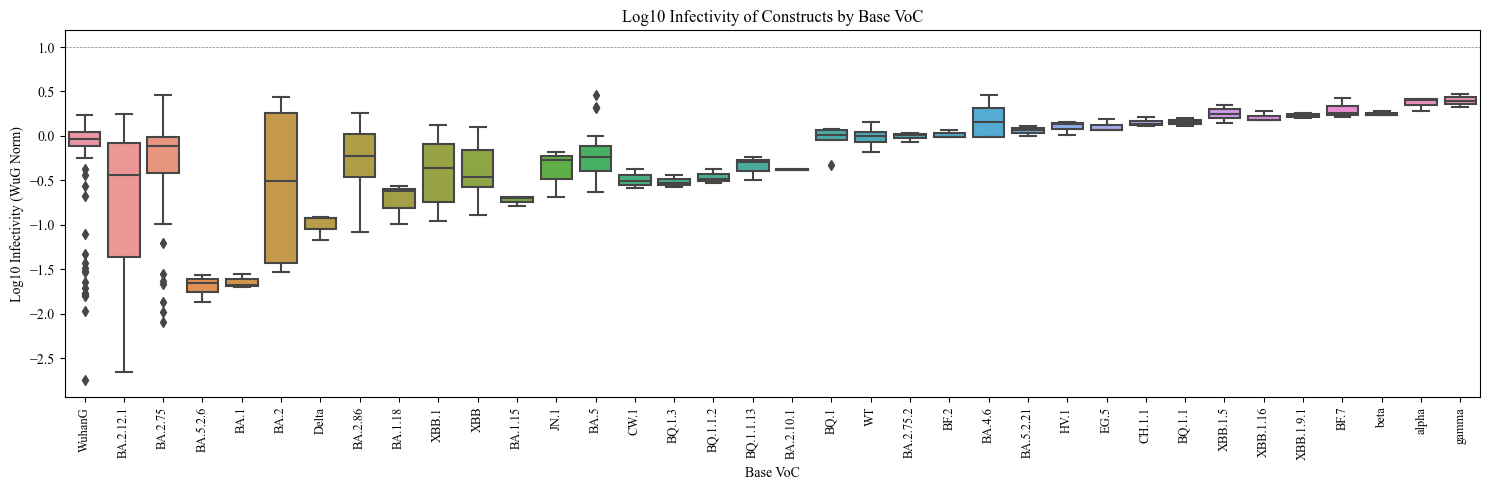

In [9]:
fig, ax = plt.subplots(figsize=(15, 5))

sns.boxplot(x='Base VoC',
            y='Log10 Infectivity (WuG Norm)',
            data=df,
            ax=ax)

xticks=ax.get_xticks()
ax.set_xticks(xticks, labels=df['Base VoC'].unique(), fontsize=9, rotation=90);
xlim = [-0.5, len(df['Base VoC'].unique())-0.5]
ax.hlines(1, xlim[0], xlim[1], color='gray', linestyle='--', linewidth=0.5)
ax.set_xlim(xlim)

ax.set_title('Log10 Infectivity of Constructs by Base VoC');
fig.tight_layout()
fig.savefig('figs/infectivity/Data_QA/infectivity_by_BaseVoC.png', dpi=150)

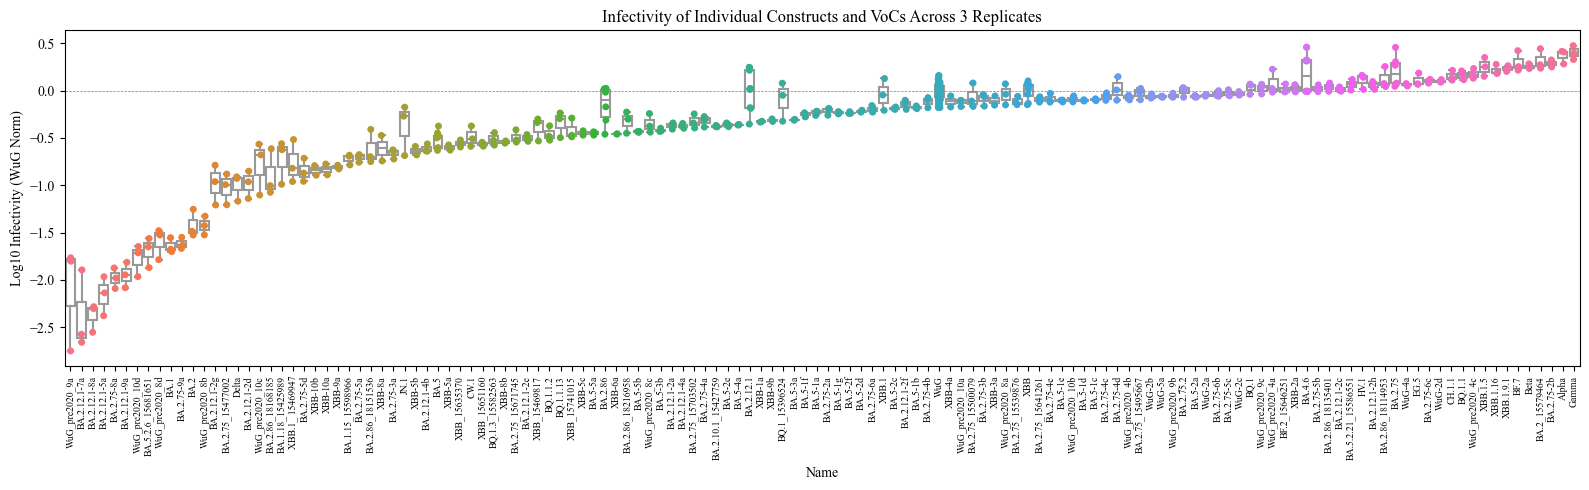

In [10]:
fig, ax = plt.subplots(1,1, figsize=(16, 5))
sns.boxplot(x='Name',
            y='Log10 Infectivity (WuG Norm)',
            data=df,
            color='white',
            ax=ax)
sns.stripplot(x='Name',
            y='Log10 Infectivity (WuG Norm)',
              hue='Name',
            data=df,
            ax=ax)
xticks=ax.get_xticks()
ax.set_xticks(xticks, labels=df['Name'].unique(), fontsize=7, rotation=90);
ax.get_legend().remove();

xlim = [-0.5, len(df['Name'].unique())-0.5]
ax.hlines(0, xlim[0], xlim[1], color='gray', linestyle='--', linewidth=0.5)
ax.set_xlim(xlim)

ax.set_title('Infectivity of Individual Constructs and VoCs Across 3 Replicates');
fig.tight_layout()
fig.savefig('figs/infectivity/Data_QA/construct_infectivity.png', dpi=150);

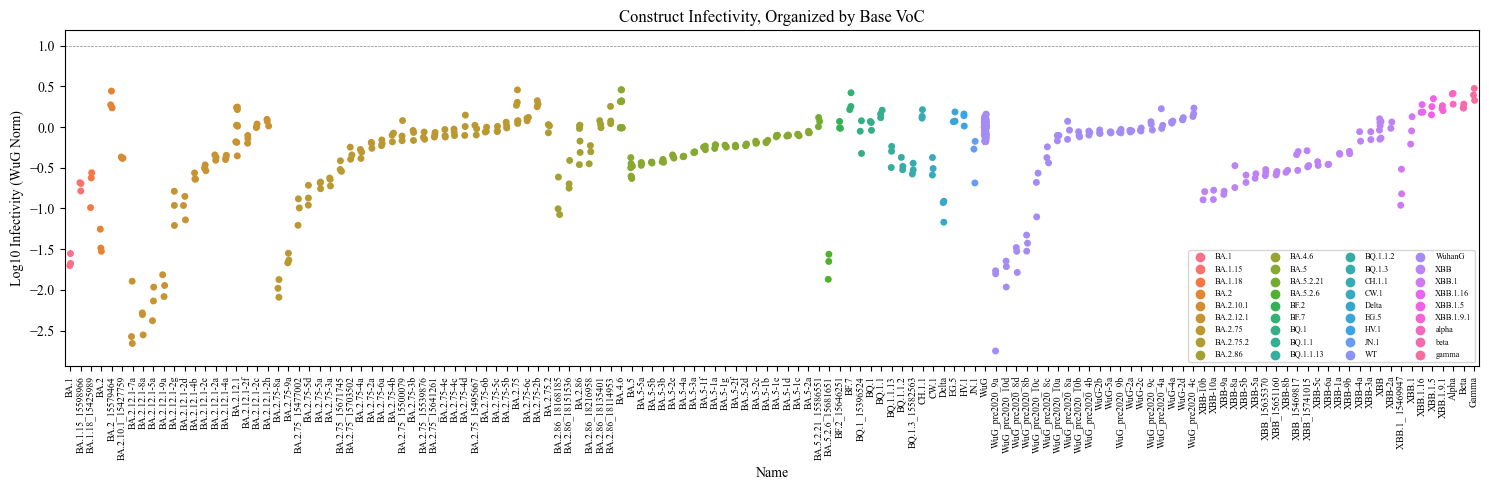

In [11]:
fig, ax = plt.subplots(figsize=(15,5))

sns.stripplot(x='Name',
              y='Log10 Infectivity (WuG Norm)',
              hue='Base VoC',
              data=df.sort_values(by=['Base VoC', 'Log10 Infectivity (WuG Norm)']),
              jitter=True,
              ax=ax)

xticks=ax.get_xticks()
ax.set_xticks(xticks, labels=df.sort_values(by=['Base VoC', 'Log10 Infectivity (WuG Norm)'])['Name'].unique(), fontsize=7, rotation=90);
ax.legend(fontsize=6, ncol=4);

xlim = [-0.5, len(df['Name'].unique())-0.5]
ax.hlines(1, xlim[0], xlim[1], color='gray', linestyle='--', linewidth=0.5)
ax.set_xlim(xlim)

ax.set_title('Construct Infectivity, Organized by Base VoC');
fig.tight_layout()
fig.savefig('figs/infectivity/Data_QA/construct_infectivity_by_BaseVoC.png', dpi=150);

---
## Model

In [12]:
def one_hot(mutations: pd.Series):
    features = sorted(list(set(','.join(filter(None, mutations.tolist())).split(','))))
    onehot = [[1 if mut.strip() in str(muts) else 0 for mut in features] for muts in mutations]
    
    return torch.tensor(onehot, dtype=d), features

def scrub_singles(X, features):
    # Remove mutations that only occur in one construct
    keep_muts = (X.sum(dim=0) > 3).nonzero()   # experiments done in triplicate 
                                                # mutations in only one construct are still seen 3 times
    print(f'Removing {len(features) - len(keep_muts)} mutations present in only one construct...')
    
    X = X[:, keep_muts].squeeze()
    features = [f for i,f in enumerate(features) if i in keep_muts]
    
    print(f'{X.shape[0]} observations')
    print(f'{X.shape[1]} mutations')
    
    return X, features

In [13]:
# Infectivity Model
def model(X,Y):
    
    # Set hyperparameters
    μ_m = 0.
    σ_m = pyro.sample('σ_m', dist.Uniform(1e-7, 2))
    μ_b = 1.
    σ_b = pyro.sample('σ_b', dist.Uniform(1e-7, 2))
    
    σ = pyro.sample("σ", dist.Uniform(1e-7, 2))
    
    # Sample mutation contribution for each mutation
    with pyro.plate("mutations", X.shape[1]):
        m = pyro.sample("m", dist.Laplace(μ_m, σ_m))
    
    # Sample baseline
    b = pyro.sample("b", dist.Normal(μ_b, σ_b))
    
    # Predict infectivity
    pred_infectivity = torch.matmul(X,m) + b
    
    # Score observations
    with pyro.plate("data", X.shape[0]):
        return pyro.sample("obs", dist.Normal(pred_infectivity, σ), obs=Y)

In [14]:
X, features = one_hot(df['All mutations'])
X, features = scrub_singles(X, features)
Y = torch.tensor(df['Log10 Infectivity (WuG Norm)'].values, dtype=d)

mcmc_data = dict()
mcmc_data['X'] = X
mcmc_data['Y'] = Y
mcmc_data['features'] = features

Removing 72 mutations present in only one construct...
511 observations
141 mutations


---
## MCMC

In [15]:
def save_mcmc(posterior_samples, mcmc_data):
    # MCMC output:
    folder = 'model_infectivity/' + dt.strftime(dt.now(), '%Y-%m-%d') + '/'
    chain_file = 'mcmc_chain.pkl'
    data_file = 'mcmc_input_data.pt'

    if not os.path.exists(folder):
        os.makedirs(folder)
        
    # Save chain
    with open(folder+chain_file, 'wb') as f:
        pickle.dump(posterior_samples, f)
    
    # Save input data for model
    torch.save(mcmc_data, folder+data_file)
    
def load_mcmc(folder):
    # MCMC output:
    chain_file = 'mcmc_chain.pkl'
    data_file = 'mcmc_input_data.pt'
        
    # Load chain
    with open(folder+chain_file, 'rb') as f:
        posterior_samples = pickle.load(f)
    
    # Load input data for model
    mcmc_data = torch.load(folder+data_file)
    
    return posterior_samples, mcmc_data

In [16]:
if run_MCMC:
    pyro.clear_param_store()
    
    nuts_kernel = NUTS(model)

    mcmc = MCMC(nuts_kernel, num_samples=1500, warmup_steps=1500)
    mcmc.run(X, Y)

    posterior_samples = mcmc.get_samples()
    
    # Save 
    save_mcmc(posterior_samples, mcmc_data)
    
else:
    posterior_samples, mcmc_data = load_mcmc(last_run_folder)
    assert (X == mcmc_data['X']).all(), 'df may have loaded differently'
    assert (Y == mcmc_data['Y']).all(), 'df may have loaded differently'
    assert features == mcmc_data['features'], 'df may have loaded differently'

Sample: 100%|████████████████████████████████████| 3000/3000 [19:12:32, 23.05s/it, step size=5.63e-03, acc. prob=0.925]


#### Inspect Traces for Convergence

5it [00:00,  8.84it/s]


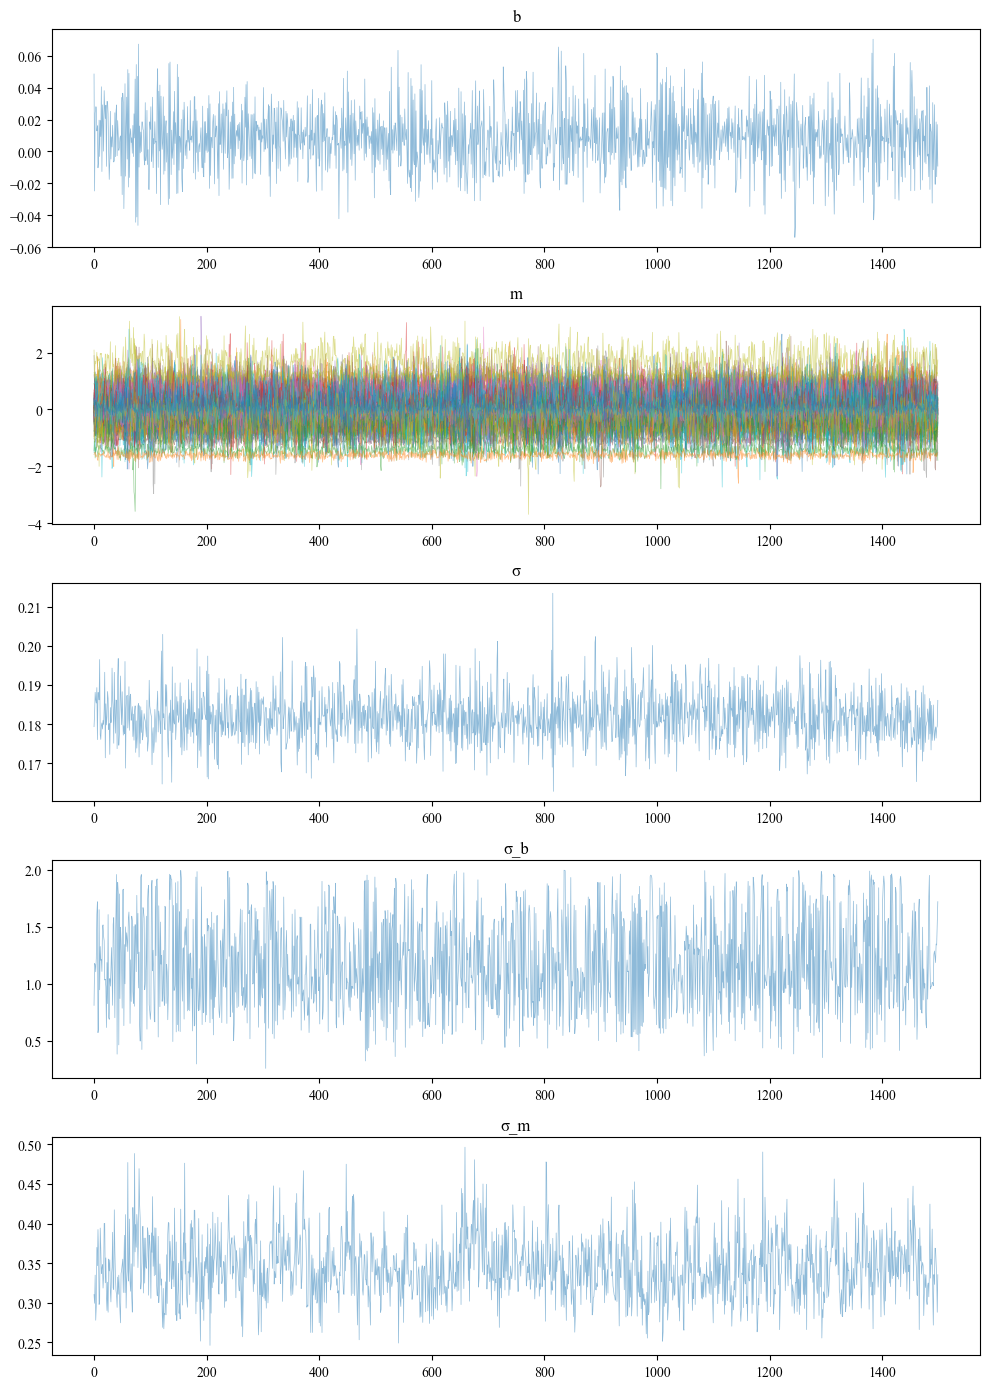

In [17]:
# Show all traces at once
def plot_trace(samples):
    num_trace = len(samples.keys())
    
    fig, axes = plt.subplots(num_trace, 1, figsize=(10, 14))
    axes = axes.flatten()
    
    def get_labels(k):
        if k.startswith('m'):
            return features
        return k
        
    for key, ax in tqdm(zip(samples.keys(),axes)):
        trace = samples[key]
        # If there are more than two dimensions, keep flattening via avg until there are only 2 dimensions
        while len(trace.shape)>2:
            trace = trace.mean(dim=-1)
            
        ax.plot(trace.detach().numpy(), label=get_labels(key), linewidth=0.5, alpha=0.5)
        ax.set_title(key)
        
        fig.tight_layout()
        
    return fig, axes
        
fig, axes = plot_trace(posterior_samples)
fig.savefig('figs/infectivity/Model_Diagnostics/infectivity_traces.png', dpi=150)

---
## Evaluate Model Fit

In [18]:
def pred_y(X, m, b):
    return torch.matmul(X,m) + b

Y_pred = pred_y(X,
                posterior_samples['m'].mean(dim=0),
                posterior_samples['b'].mean(dim=0),
               )

In [19]:
sse = sum((Y_pred - Y)**2)
avg_err = sum((Y_pred - Y)**2).sqrt() / len(Y)
print('SSE: {:.2f}'.format(sse))
print('Avg abs Error Per Obs: {:.4f}'.format(avg_err))

SSE: 14.33
Avg abs Error Per Obs: 0.0074


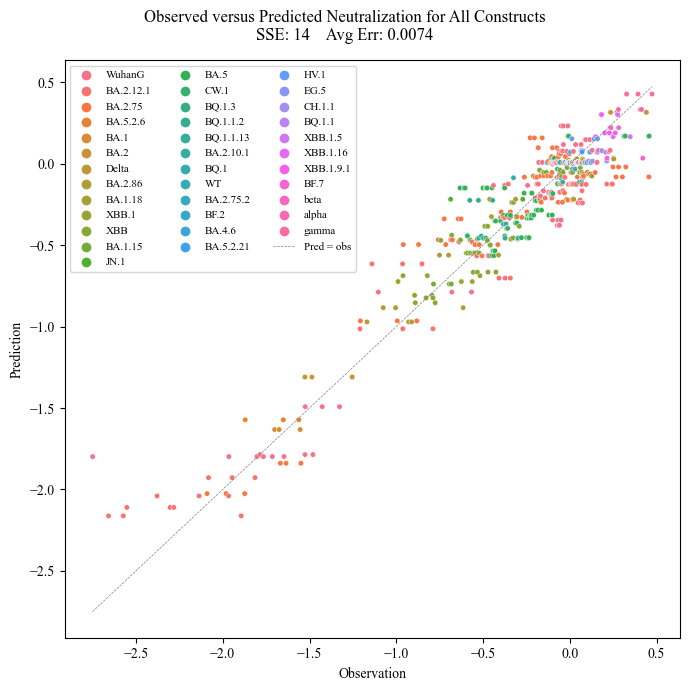

In [21]:
# QQ Plot
def qqplot(ax):
    sns.scatterplot(x='Observation',
                y='Prediction',
                hue='Base VoC',
                s=15,
                alpha=1,
                data=pd.concat([df.reset_index(drop=True), pd.Series(Y_pred)], axis=1).rename(columns={'Log10 Infectivity (WuG Norm)':'Observation', 0:'Prediction'}),
                ax=ax
               )
    mi, ma = min(torch.cat([Y, Y_pred])), max(torch.cat([Y, Y_pred])) 
    ax.plot([mi, ma], [mi, ma], linestyle='--', linewidth=0.5, color='gray', label='Pred = obs')
    ax.legend(ncol=3, fontsize=8)
    ax.set_xlabel('Observation');
    ax.set_ylabel('Prediction');
    
fig, ax = plt.subplots(figsize=(7, 7))
qqplot(ax)
fig.suptitle('Observed versus Predicted Neutralization for All Constructs\nSSE: {:,.0f}    Avg Err: {:.4f}'.format(sse, avg_err))
fig.tight_layout()
fig.savefig('figs/infectivity/Model_Diagnostics/predictions_vs_observations.png', dpi=150)

#### Sample posterior to make predictions

In [22]:
def align_features(X, features, features_ref):
    indexer = [i for i, f in enumerate(features) if f in features_ref]
    X = X[:,indexer]
    features = [f for f in features if f in features_ref]
    
    return X, features

In [23]:
df_pred = df[['Name', 'Base VoC', 'All mutations']].drop_duplicates()
X_pred, features_pred = one_hot(df_pred['All mutations'])
X_pred, features_pred = align_features(X_pred, features_pred, features)

predictive = Predictive(model, posterior_samples, return_sites=["σ", "obs"])
samples_predictive = predictive(X_pred, None)

predictive_df = pd.DataFrame(data=samples_predictive['obs'], columns=df_pred['Name'].to_list())
predictions = pd.melt(predictive_df, var_name='Name', value_name='Prediction')

df_pred = pd.concat([df_pred.reset_index(drop=True), pd.Series(samples_predictive['obs'].mean(dim=0))], axis=1).rename(columns={0:"Predicted Mean"})
predictions = pd.merge(predictions, df_pred, on='Name', how='inner')
predictions = pd.merge(predictions, df, on=['Name', 'Base VoC', 'All mutations']).rename(columns={'Log10 Infectivity (WuG Norm)':'Observation'}).sort_values(by='Predicted Mean').reset_index(drop=True)

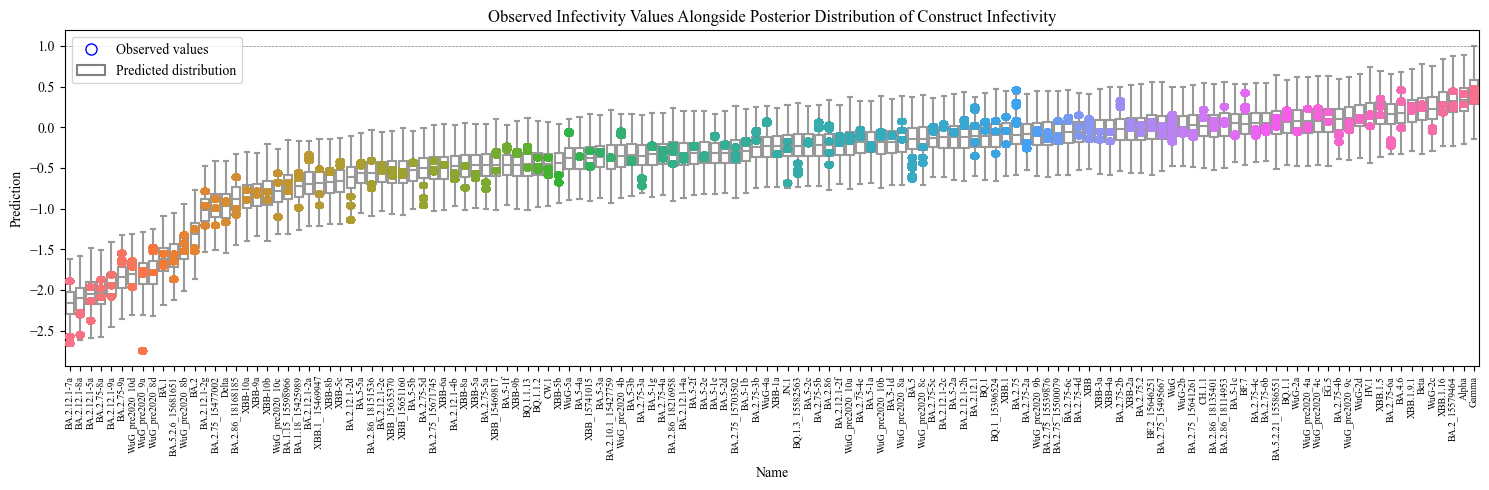

In [24]:
fig, ax = plt.subplots(figsize=(15,5))

sns.boxplot(x='Name',
            y='Prediction',
            data=predictions,
            color='white',
            showfliers=False,
            ax=ax)
sns.stripplot(x='Name',
            y='Observation',
              hue='Name',
            data=predictions,
            ax=ax)

xlim = [-0.5, len(df['Name'].unique())-0.5]
ax.hlines(1, xlim[0], xlim[1], color='gray', linestyle='--', linewidth=0.5)
# ax.set_xlim(xlim)

xticks=ax.get_xticks()
ax.set_xticks(xticks, labels=predictions['Name'].unique(), fontsize=7, rotation=90);
# ax.get_legend().remove();

# Create custom legend
legend_elements = [Line2D([0], [0], 
                          marker='o', color='white', markeredgecolor='blue', markerfacecolor='white', markersize=8, 
                          label='Observed values'),
                   Patch(
                       facecolor='white', edgecolor='gray', linewidth=1.5,
                       label='Predicted distribution')
                   ]

# Add legend to the plot
ax.legend(handles=legend_elements, loc='upper left');

# Add title
ax.set_title('Observed Infectivity Values Alongside Posterior Distribution of Construct Infectivity');

# Save
fig.tight_layout()
fig.savefig('figs/infectivity/Model_Diagnostics/observations_over_construct_posterior.png', dpi=150);

---
## Save CSVs of Results

In [25]:
def mutation_effects(samples, features, X):
    effects = pd.DataFrame(zip(features_pred, 
                              [x.item() for x in samples.mean(dim=0)],
                              [x.item() for x in X.sum(dim=0)])
                          ).rename(columns={0:"Mutation",1:"Effect",2:"N"}
                          ).sort_values(by='Effect', ascending=False)
    return effects

def baseline_effect(samples, X):
    effect_b = pd.DataFrame()
    effect_b['Constant'] = ['b']
    effect_b['Value'] = [samples.mean().item()]
    effect_b['N'] = [X.shape[0]]
    return effect_b

In [26]:
outfolder = 'results/infectivity/' + dt.strftime(dt.now(), '%Y-%m-%d') + '/'
if not os.path.exists(outfolder):
    os.makedirs(outfolder)
    
# Mutations
outfile = 'mutation_effects.csv'
effects = mutation_effects(posterior_samples['m'], features, X)
effects.to_csv(outfolder + outfile, index=False)

# Baseline
outfile = 'baseline_effect.csv'
effect_b = baseline_effect(posterior_samples['b'], X)
effect_b.to_csv(outfolder + outfile, index=False)

---
## Explore Model Results

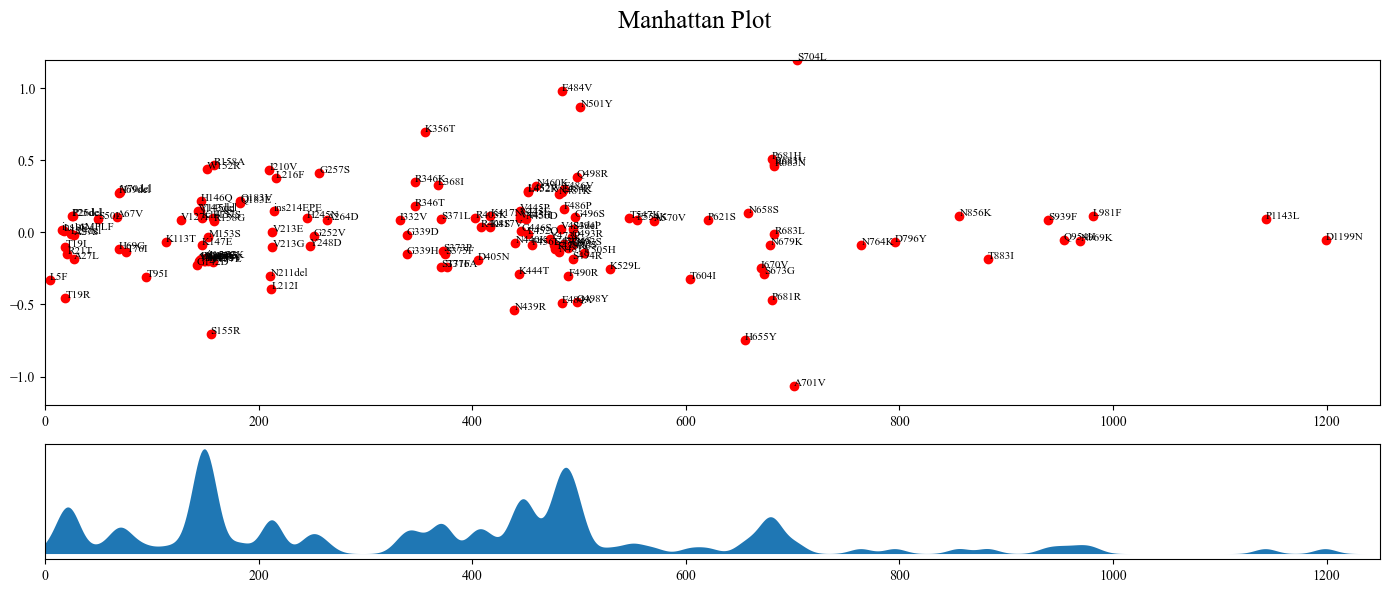

In [27]:
# Manhattan plot
def setup():
    fig, axes = plt.subplots(2,1, figsize=(14,6), gridspec_kw={'height_ratios': [4.5, 1.5]})
    
    options= dict()
    options['xlim'] = [0, 1250]
    options['ylim'] = [-1.2, 1.2]#[-1, 1]
    
    axes[0].set_xlim(options['xlim'])
    axes[0].set_ylim(options['ylim'])
    
    axes[1].set_xlim(options['xlim'])
    axes[1].set_yticks([])
    
    return fig, axes, options

def preprocess_manhattan(samples, labels):
    means = samples.mean(dim=0)
    coefficients = labels.copy()
    
    positions = [int(''.join(filter(str.isdigit, c))) for c in coefficients] #[int(c[1:-1]) for c in coefficients]
    return means, positions, coefficients

def plot_coef(ax, means, positions, coefficients, optoins):
    ax.plot(positions, means, 'ro')
    
    texts = []
    for i, (pos, fea) in enumerate(zip(positions, coefficients)):
        x = pos
        y = means[i]
        text = fea #+ '\n' + '{:1.2f}'.format(y)
        texts.append(ax.annotate(text, xy=(x, y), xytext=(x, y), fontsize=8))

    # adjust_text(texts);
    
    ax.set_xlim(options['xlim'])
    
def plot_density(ax, positions, options):
    xlim = options['xlim']
    ylim = options['ylim']
    num_points=1000
    # Fit KDE
    kde = KDE(kernel='gaussian', bandwidth=10).fit(np.array(positions).reshape(-1,1))
    x = np.linspace(xlim[0], xlim[1], num_points).reshape(-1,1)
    # Generate KDE curve
    y = np.exp(kde.score_samples(x))
    
    ax.fill_between(x.flatten(), np.zeros_like(y), y)
    
    return kde


fig, axes, options = setup()
all_means, positions, coefficients = preprocess_manhattan(posterior_samples['m'], features)
kde = plot_density(axes[1], positions, options)
plot_coef(axes[0], all_means, positions, coefficients, options)
fig.suptitle('Manhattan Plot', fontsize=18)
fig.tight_layout()
fig.savefig('figs/infectivity/Results/Manhattan.png', dpi=150)

142it [00:03, 43.45it/s]
100%|████████████████████████████████████████████████████████████████████████████████| 142/142 [00:01<00:00, 99.69it/s]


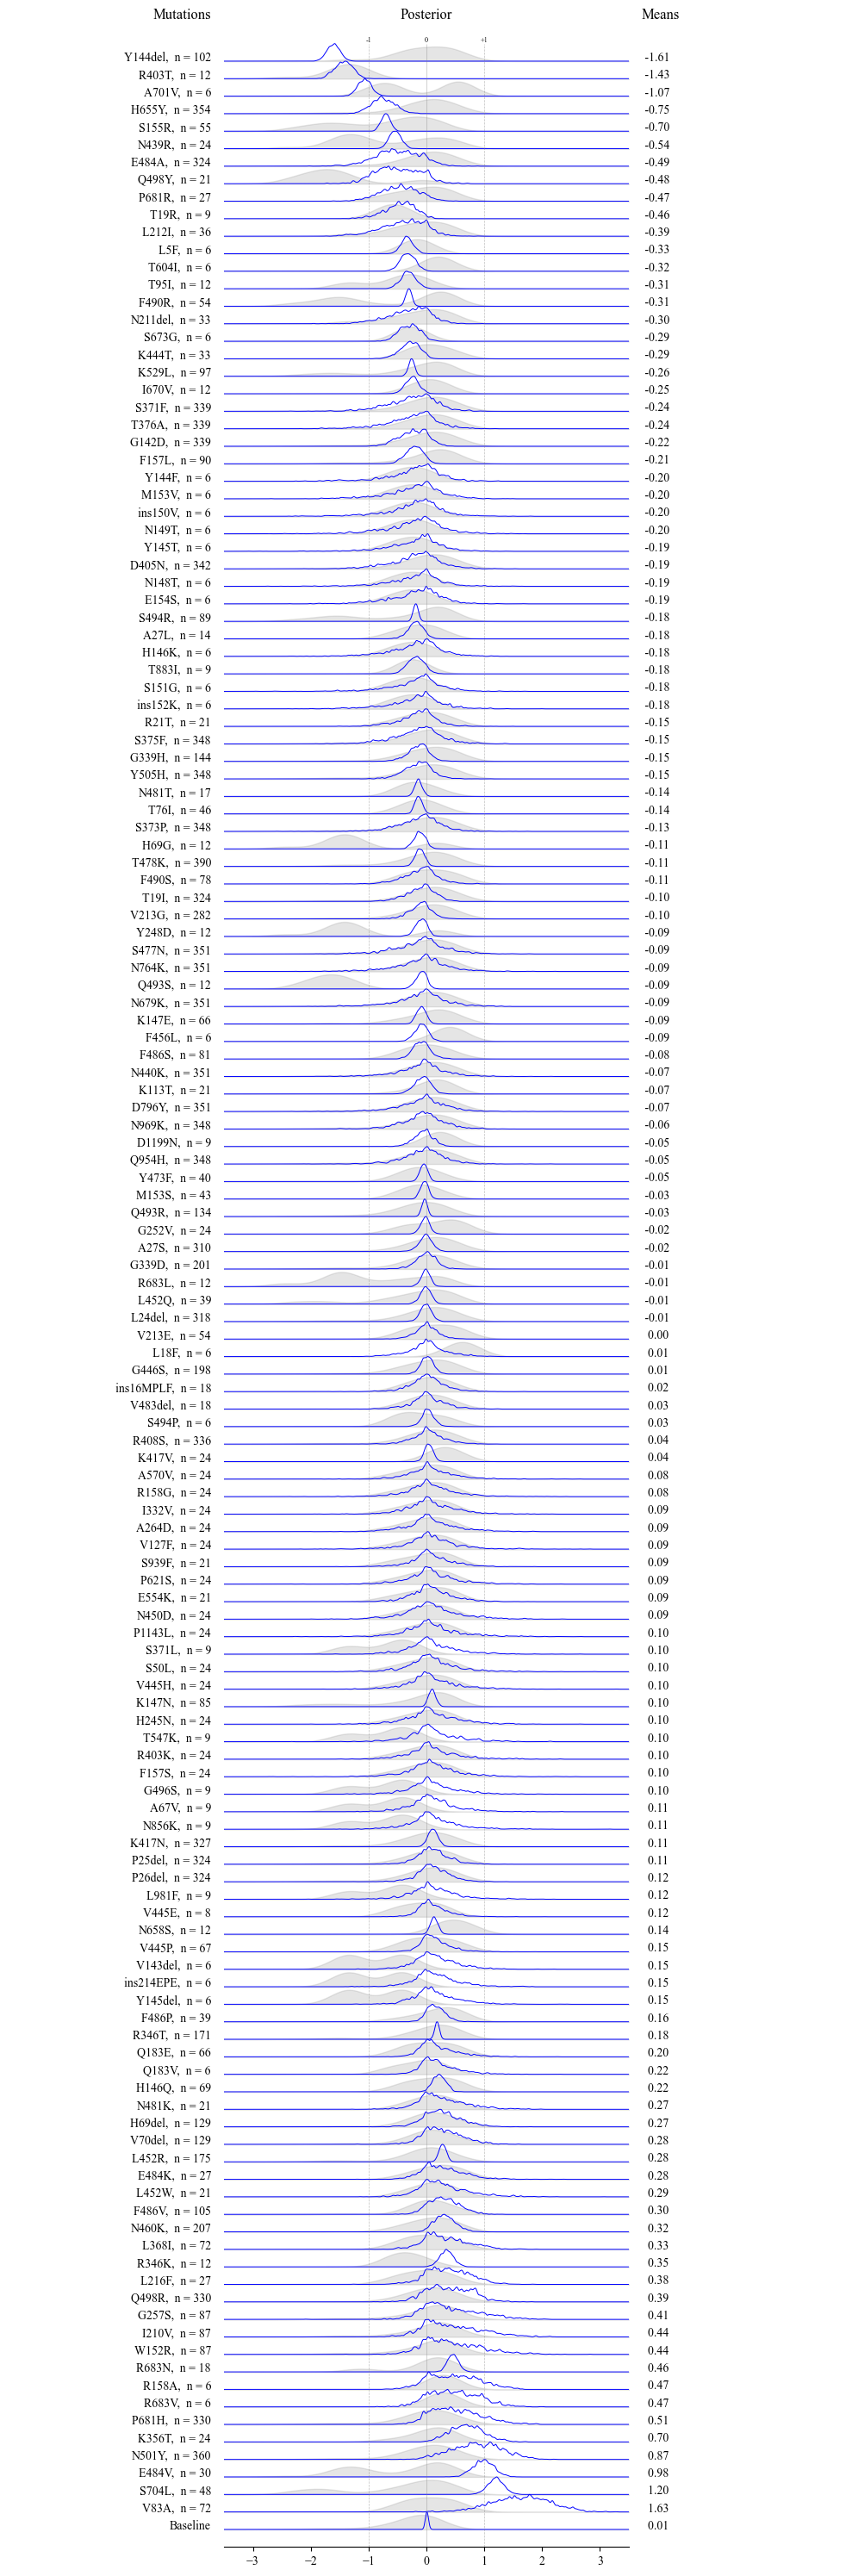

In [31]:
def preprocess_kde(samples, labels):
    m_samples = samples['m']
    b_samples = samples['b'].unsqueeze(dim=1)
    all_samples = torch.cat((m_samples, b_samples), dim=1)  # put β at the end
    coefficients = labels.copy()
    sort_by = all_samples.mean(dim=0)
    sort_by = sort_by[:-1]  # intercept is the last term in this tensor
    coef_map = {x:i for i, (_,x) in enumerate(sorted(zip(sort_by, labels)))}#, reverse=True))}
    # Add intercept term last
    coef_map['Baseline'] = len(coefficients)
    coefficients.append('Baseline')
    return all_samples, coefficients, coef_map

def setup(fig, axes, samples):
    options = {}
    options['scale'] = 1
    options['xlim'] = [-3.5, 3.5]
    options['ymax'] = samples.shape[1]
    
    axes[1].spines.right.set_visible(False)
    axes[1].spines.left.set_visible(False)
    axes[1].spines.top.set_visible(False)
    axes[1].set_yticks([])
    axes[1].set_yticklabels([])
    
    axes[0].axis('off')
    axes[2].axis('off')
    
    plt.rcParams['font.family'] = ['Times New Roman']
    return options

def plot_kdes(ax, samples, coefficients, coef_map, options):
    scale = options['scale']
    ymax = options['ymax']
    xlim = options['xlim']
    num_points = 1000
    color='blue'
    
    linecolor = 'blue'
    linewidth = 0.7
    
    for i, coef in tqdm(enumerate(coefficients)):
        base_y = (ymax - coef_map[coef])  # coef_map[coef]  
        sample_idx = i
        # Fit KDE
        s = samples[:, sample_idx]
        kde = KDE(kernel='gaussian', bandwidth=0.02).fit(s.reshape(-1,1))
        x = np.linspace(xlim[0], xlim[1], num_points).reshape(-1,1)
        # Generate KDE curve
        y = np.exp(kde.score_samples(x))
        # Scale curve
        y /= (scale*max(y))
        # Move y up to the desired height
        y += base_y
        
        
        ax.plot(x, y, 
                color=color, linewidth=linewidth)
        
    ax.set_xlim(xlim)
    ax.set_ylim([0, options['ymax']+2])
    ax.set_title('Posterior', loc='center')
    
def annotate_means(ax, samples, coefficients, coef_map, options):
    scale = options['scale']
    ymax = options['ymax']
    fontsize = 8
    
    means = {}
    coefs = list(coef_map.keys())
    for i, c in enumerate(coefficients):
        mean = samples[:,i].mean()
        means[c] = mean.item()
        t = '{:6.2f}'.format(mean)
        y = ymax - coef_map[c]
        ax.text(0, y, t,
                ha='left')
        
    ax.set_xlim([0,1])
    ax.set_ylim([0, options['ymax']+2])
    ax.set_title('Means', loc='left')
    
    return means
    
def affordances(ax, options):
    ax.vlines(0, 0, options['ymax']+options['scale'],
             color='gray', linewidth=0.5, alpha=0.5)
    ax.vlines(1, 0, options['ymax']+options['scale'],
             color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.vlines(-1, 0, options['ymax']+options['scale'],
             color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.text(0, options['ymax']+options['scale'], '0', ha='center', va='bottom', fontsize=6)
    ax.text(1, options['ymax']+options['scale'], '+1', ha='center', va='bottom', fontsize=6)
    ax.text(-1, options['ymax']+options['scale'], '-1', ha='center', va='bottom', fontsize=6)

def annotate_posterior_with_n(ax, coefficients, coef_map, X, features, options):
    scale = options['scale']
    ymax = options['ymax']
    fontsize = 8
    
    pos = [ymax - i for i in range(ymax)]
    labels = list(coef_map.keys())
    for y, t in zip(pos, labels):
        if t in features:
            i = features.index(t)
            n=X.sum(dim=0)[i]
            t = t + f',  n = {int(n)}'
            
            # f'n={int(n)}'.ljust(10)
        
        ax.text(1, y, t,
                ha='right')
        
    ax.set_xlim([0,1])
    ax.set_ylim([0, options['ymax']+2])
    ax.set_title('Mutations', loc='right')

def get_obs(df):
    mean_inf = df['Log10 Infectivity (WuG Norm)'].mean()
    df2 = df.copy()
    df2['Relative Infectivity'] = df2['Log10 Infectivity (WuG Norm)'].apply(lambda x: x - mean_inf)
    
    return df2

def kde_obs(ax, obs, coef_map, options):
    scale = options['scale']+0.2
    ymax = options['ymax']
    xlim = options['xlim']
    num_points = 1000
    color='blue'
    
    linecolor = 'gray'
    linewidth = 0.7

    for coef in tqdm(coefficients):
        base_y = (ymax - coef_map[coef])  # coef_map[coef]  
        
        if coef.startswith('Baseline'):
            s = obs['Log10 Infectivity (WuG Norm)']
        else:
            s = obs[obs['All mutations'].apply(lambda x: coef in x if isinstance(x, str) else False)]['Relative Infectivity']
        
        s = np.array(s)
        kde = KDE(kernel='gaussian', bandwidth=0.3).fit(s.reshape(-1,1))
        x = np.linspace(xlim[0], xlim[1], num_points)
        # Generate KDE curve
        y = np.exp(kde.score_samples(x.reshape(-1,1)))
        # Scale curve
        y /= (scale*max(y))
        # Move y up to the desired height
        y += base_y
        
        
        # ax.plot(x, y, 
        #         color=color, linewidth=linewidth, alpha=0.5)
        ax.fill_between(x,
                        base_y, 
                        y, 
                        color='gray', alpha=0.2);
        
        
all_samples, coefficients, coefficient_map = preprocess_kde(posterior_samples, features)

fig, axes = plt.subplots(1, 3, figsize=(10, 30), gridspec_kw={'width_ratios': [1, 2, 1]})

options = setup(fig, axes, all_samples)
plot_kdes(axes[1], all_samples, coefficients, coefficient_map, options)
annotate_posterior_with_n(axes[0], coefficients, coefficient_map, X, features, options)
means = annotate_means(axes[2], all_samples, coefficients, coefficient_map, options)
affordances(axes[1], options)

obs = get_obs(df)
kde_obs(axes[1], obs, coefficient_map, options)

fig.tight_layout()
fig.savefig('figs/infectivity/Results/posterior_with_observations.png', dpi=150)

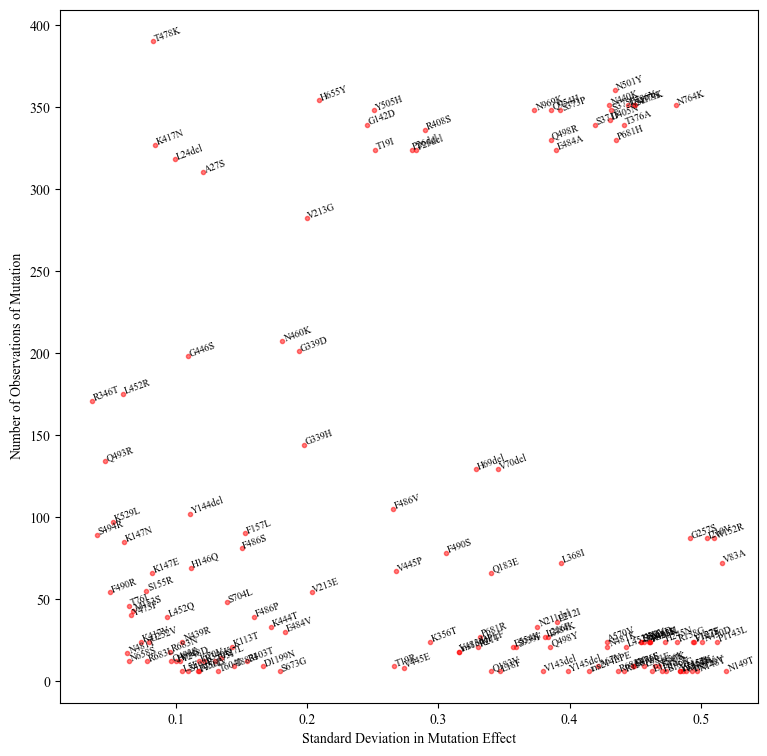

In [30]:
# Volcano Plots
fig, ax = plt.subplots(figsize=(9,9))
n = X.sum(dim=0)
ax.plot(posterior_samples['m'].std(dim=0), n,
        marker='o', color='red', markersize=3, alpha=0.5,
        linestyle='');

for i, f in enumerate(features):
    # if n[i] > 750 or posterior_samples['m'].std(dim=0)[i] < 0.5:
    ax.text(posterior_samples['m'].std(dim=0)[i],
            n[i],
            f,
            fontsize=7,
            rotation=20)

ax.set_xlabel('Standard Deviation in Mutation Effect');
ax.set_ylabel('Number of Observations of Mutation');

fig.savefig('figs/infectivity/Results/not-volcano.png', dpi=150)